# Notebook 20 — Carbonate-extended box model + 7-tracer joint loss (Eq Pacific) — Track 1 v2.0

**Goal.** nb19 showed a 4-tracer joint loss partially collapses parameter degeneracy: 3/6 Carroll-6 means moved closer to Carroll's published, but the iron pair (`alpfe`, `scav_rat`) stayed 2–3× off because Chl + FeT + POC + PIC don't directly constrain the carbonate side of the system. This notebook adds DIC + ALK + air-sea CO₂ flux as three new constraints — the signals Carroll 2022 was actually calibrated against — and tests whether the carbonate-extended box-model + 7-tracer joint loss closes the remaining recovery gap.

**Hypothesis.** Extending carroll6 to a 7-tracer state (`[DFe, Ps, Pl, POC, PIC, DIC, ALK]`) with carbonate equilibrium (Follows 2006) and air-sea flux (Wanninkhof 2014) adds three new loss surfaces tied to the Carroll-6 parameters via:
- DIC depletion via phyto C fixation (`Smallgrow`, `Biggrow`)
- DIC + ALK drained by CaCO₃ formation (`R_PICPOC`)
- pCO₂_ocean → air-sea flux modulated indirectly by all six knobs

If these are the binding constraints on the iron pair, the recovered means should move toward Carroll's published values. If they don't, the ceiling is somewhere we haven't identified yet (depth-resolved iron observations are the prime suspect, cluster-gated).

**Loss target — 7 tracers:**

| Box-model output | Darwin field | Source |
|---|---|---|
| `state[0]` (DFe) | `FeT` | LLC270 native, binned to 1° |
| `state[1] + state[2]` (Ps + Pl) | `Chl_total` | bin_average (sum of Chl1–Chl5) |
| `state[3]` (POC) | `POC` | LLC270 native, binned to 1° |
| `state[4]` (PIC) | `PIC` | LLC270 native, binned to 1° |
| `state[5]` (DIC) | `DIC` | LLC270 native, binned to 1° |
| `state[6]` (ALK) | `ALK` | LLC270 native, binned to 1° |
| `co2_flux(pCO2_ocean(state), pCO2_atm)` | `CO2_flux` | bin_average |

**Headline experiment: DINN baseline** (1×1 conv, SST input, ~400 params). Can't saturate → recovered Carroll-6 means carry identifiability information. Compare directly to nb14 (DINN baseline, FeT-only) to isolate the carbonate effect.

**Secondary experiment: DINNDeep** (4-channel input, ~9.4K params). Continues the nb15→19 saturation line. r → 1.000 expected; this is the ceiling demo, not the recovery-grade claim.

**Success criteria for the headline (DINN baseline + 7-tracer joint loss):**
- Iron pair `alpfe`, `scav_rat` move **closer** to Carroll's published than the nb14 / nb19 baselines → carbonate is the missing constraint → v2.0 result.
- They don't move → iron-pair identifiability needs something we don't have locally (depth-resolved obs).

**Builds on:** nb14 (DINN baseline FeT-only, iron-pair recovery in HNLC), nb19 (DINNDeep 4-tracer joint loss), Day 1 (carbonate solver), Day 2 (`carroll6_carbonate_integrate`), Day 3 (`bin_native_tracer_to_1deg`).


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from darwindiff.carbonate import PCO2_ATM_DEFAULT, co2_flux, solve_carbonate
from darwindiff.carroll6 import (
    CARROLL_VALUES,
    H_MLD,
    PARAM_BOUNDS,
    PARAM_NAMES,
    bounded_params,
    carroll6_carbonate_integrate,
)
from darwindiff.diagnostics import format_pearson, safe_pearson_r
from darwindiff.ecco_darwin_loader import (
    EQUATORIAL_PACIFIC_AOI,
    ocean_mask as bin_ocean_mask,
    open_bin_average,
    subset_aoi,
    time_mean,
    total_chlorophyll,
)
from darwindiff.llc270_loader import bin_native_tracer_to_1deg
from darwindiff.networks import DINN, DINNDeep

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

AOI = EQUATORIAL_PACIFIC_AOI
print(f"AOI: {AOI.name} ({AOI.lat_min}-{AOI.lat_max} N, {AOI.lon_min}-{AOI.lon_max} E)")


Device: cuda
GPU: NVIDIA GeForce RTX 5090 Laptop GPU
AOI: Equatorial Pacific (-5.0-15.0 N, -160.0--110.0 E)


## 1. Load Eq Pacific climatology — 7 targets + covariates

bin_average provides surface 1° fields directly: SST, MLD, wind, pCO₂_atm, CO₂_flux, and Chl₁–Chl₅. LLC270 native provides depth-resolved tracers (FeT, POC, PIC, DIC, ALK); we bin-average these to the same 1° grid via `bin_native_tracer_to_1deg` (Day 3 deliverable). Combined ocean mask = cells where all 7 targets AND all forcing fields are finite.


In [2]:
DATA_ROOT = Path(os.environ.get("DARWIN_DATA_ROOT", r"D:\\ecco_darwin_v5"))
BIN_AVG_PATH = str(DATA_ROOT / "bin_average" / "v05_ECCO-Darwin_bin_average_1x1_deg.nc")
MONTHLY_ROOT = str(DATA_ROOT / "output" / "monthly")
GRID_DIR = str(DATA_ROOT / "grid")

# === Covariates + carbonate targets from bin_average ===
ds_bin = open_bin_average(BIN_AVG_PATH)
eqpac_clim = time_mean(subset_aoi(ds_bin, AOI))

sst = eqpac_clim.SST.values.astype(np.float64)
mld = eqpac_clim.mldDepth.values.astype(np.float64)
wind = eqpac_clim.windSpeed.values.astype(np.float64)
sss = eqpac_clim.SSS.values.astype(np.float64)
co2_flux_obs = eqpac_clim.CO2_flux.values.astype(np.float64)  # mol C / m^2 / s
pco2_atm_field = eqpac_clim.apCO2.values.astype(np.float64) * 1.0e6  # atm -> uatm
chl_total = total_chlorophyll(eqpac_clim).values.astype(np.float64)

lat_1d = eqpac_clim.lat.values.astype(np.float64)
lat_2d = np.broadcast_to(lat_1d[:, None], sst.shape).astype(np.float64)
print(f"bin_average covariates + carbonate targets loaded: shape = {sst.shape}")

# === Native LLC270 tracers binned to 1° (5 fields: FeT, POC, PIC, DIC, ALK) ===
print("Loading native LLC270 tracers (FeT, POC, PIC, DIC, ALK)...")
native_targets = {}
for var in ["FeT", "POC", "PIC", "DIC", "ALK"]:
    native_targets[var] = bin_native_tracer_to_1deg(
        monthly_root=MONTHLY_ROOT,
        grid_dir=GRID_DIR,
        variable=var,
        lat_min=AOI.lat_min, lat_max=AOI.lat_max,
        lon_min=AOI.lon_min, lon_max=AOI.lon_max,
        iters="all",
    )
    print(f"  {var}: shape={native_targets[var].shape}, finite={int(np.isfinite(native_targets[var]).sum())}")

fet_binned = native_targets["FeT"]
poc_binned = native_targets["POC"]
pic_binned = native_targets["PIC"]
dic_binned = native_targets["DIC"]
alk_binned = native_targets["ALK"]

# Convert Darwin's CO2_flux units (mol C / m^2 / s) to our box-model output
# units (mmol C / m^2 / s) for direct comparison without re-scaling.
co2_flux_obs = co2_flux_obs * 1.0e3

# Combined ocean mask: every target AND every covariate must be finite.
ocean_mask = (
    np.isfinite(sst) & np.isfinite(mld) & np.isfinite(wind) & np.isfinite(sss)
    & np.isfinite(pco2_atm_field) & np.isfinite(co2_flux_obs)
    & np.isfinite(chl_total)
    & np.isfinite(fet_binned) & np.isfinite(poc_binned) & np.isfinite(pic_binned)
    & np.isfinite(dic_binned) & np.isfinite(alk_binned)
)
n_ocean = int(ocean_mask.sum())
print(f"\nCombined ocean cells (all 7 targets + 5 forcing fields finite): {n_ocean} of {ocean_mask.size}")

print("\nTarget magnitudes over ocean mask:")
for name, a in [("FeT", fet_binned), ("Chl_total", chl_total), ("POC", poc_binned),
                ("PIC", pic_binned), ("DIC", dic_binned), ("ALK", alk_binned),
                ("CO2_flux", co2_flux_obs)]:
    o = a[ocean_mask]
    print(f"  {name:>10s}: mean {o.mean():.3e}, std {o.std():.3e}, range [{o.min():.3e}, {o.max():.3e}]")


bin_average covariates + carbonate targets loaded: shape = (21, 51)
Loading native LLC270 tracers (FeT, POC, PIC, DIC, ALK)...


C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("C

C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("C

C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("C

C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\FeT or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("C

...

C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\ALK or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in D:\ecco_darwin_v5\output\monthly\ALK or D:\ecco_darwin_v5\grid. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "


C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\xmitgcm\mds_store.py:265: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds = xr.combine_by_coords(datasets, compat='override', coords='minimal', combine_attrs='drop_conflicts')


C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 50
  result = blockwise(
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(


C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 50
  result = blockwise(
C:\Users\Frank\OneDrive\Desktop\Github\ecco-darwindiff\.claude\worktrees\pensive-bouman-43f235\.venv\Lib\site-packages\dask\array\core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(


  ALK: shape=(21, 51), finite=1071

Combined ocean cells (all 7 targets + 5 forcing fields finite): 1071 of 1071

Target magnitudes over ocean mask:
         FeT: mean 7.290e-06, std 1.743e-05, range [1.639e-06, 1.628e-04]
   Chl_total: mean 1.361e-01, std 1.020e-01, range [6.792e-02, 5.075e-01]
         POC: mean 1.213e-01, std 7.223e-02, range [3.394e-02, 4.397e-01]
         PIC: mean 4.023e-03, std 3.698e-03, range [4.835e-05, 2.062e-02]
         DIC: mean 2.022e+03, std 5.072e+01, range [1.939e+03, 2.102e+03]
         ALK: mean 2.336e+03, std 4.009e+01, range [2.257e+03, 2.393e+03]
    CO2_flux: mean 2.864e-02, std 4.239e-02, range [-4.700e-02, 1.126e-01]


## 2. Build training tensors and z-score the 7 targets

The DINN baseline takes SST only (1-channel input); DINNDeep takes SST + MLD + wind + lat (4-channel). Both use the same per-cell forcing fields (T, S, wind, pCO₂_atm) and the same 7-target z-scored loss. Initial state is the surface-ocean reference matching the carbonate solver tests.


In [3]:
def normalize_covariate(arr, mask):
    o = arr[mask]
    return np.where(mask, (arr - o.mean()) / max(o.std(), 1e-6), 0.0).astype(np.float32)


sst_norm = normalize_covariate(sst, ocean_mask)
mld_norm = normalize_covariate(mld, ocean_mask)
wind_norm = normalize_covariate(wind, ocean_mask)
lat_norm = normalize_covariate(lat_2d, ocean_mask)

env_1ch = torch.tensor(sst_norm, dtype=torch.float32).unsqueeze(0)
env_4ch = torch.tensor(np.stack([sst_norm, mld_norm, wind_norm, lat_norm], axis=0),
                       dtype=torch.float32)

mask_t = torch.tensor(ocean_mask, dtype=torch.bool)
H, W = env_1ch.shape[1], env_1ch.shape[2]

# 7-tracer initial state, matching the Day 2 test_carroll6_carbonate fixture.
state0 = torch.tensor([
    5.0e-4,           # DFe
    1.0, 1.0,         # Ps, Pl
    0.5, 0.025,       # POC, PIC
    2050.0 * 1.025,   # DIC (~2050 umol/kg)
    2350.0 * 1.025,   # ALK (~2350 umol/kg)
]).reshape(7, 1, 1).expand(7, H, W).contiguous()

# Forcing fields (per-cell). Keep on device for the inner loop.
# NaN-safe land-cell fill: bin_average has NaN at land. solve_carbonate'''s
# torch.log(T) propagates NaN through the integration even at masked cells
# (IEEE 754: NaN * 0 = NaN), so the masked loss term becomes NaN and Adam
# silently does nothing. Replace land-cell NaN with neutral surface-ocean
# defaults — those cells get masked out of the loss anyway, so the specific
# value doesn'''t affect the recovery. Required for any AOI with coastal land
# (Eq Pacific 5S-15N x 160W-110W happens to have zero land at 1deg, but
# Mid-Atl / N Pac / full-ocean all have coastal cells).
T_field = torch.tensor(np.where(np.isfinite(sst), sst, 15.0).astype(np.float32))
S_field = torch.tensor(np.where(np.isfinite(sss), sss, 35.0).astype(np.float32))
wind_field = torch.tensor(np.where(np.isfinite(wind), wind, 7.0).astype(np.float32))
pco2_atm_t = torch.tensor(np.where(np.isfinite(pco2_atm_field), pco2_atm_field, PCO2_ATM_DEFAULT).astype(np.float32))

env_1ch_dev = env_1ch.to(device)
env_4ch_dev = env_4ch.to(device)
state0_dev = state0.to(device)
mask_dev = mask_t.to(device)
bounds_dev = PARAM_BOUNDS.to(device)
T_dev = T_field.to(device)
S_dev = S_field.to(device)
wind_dev = wind_field.to(device)
pco2_atm_dev = pco2_atm_t.to(device)


def to_z_target(np_field):
    """Z-score over ocean cells; replace non-ocean with finite zero so torch is happy.

    Same pattern as nb19. No train/val split here — this is a single-fit
    closeout; the block-CV story is Day 5 of the v2.0 closeout (separate notebook).
    """
    clean = np.where(ocean_mask, np_field, 1.0).astype(np.float32)
    t = torch.tensor(clean, dtype=torch.float32).to(device)
    o = t[mask_dev]
    mean = o.mean()
    std = o.std().clamp(min=1e-6)
    return (t - mean) / std, float(mean), float(std)


fet_z, fet_mean, fet_std = to_z_target(fet_binned)
chl_z, chl_mean, chl_std = to_z_target(chl_total)
poc_z, poc_mean, poc_std = to_z_target(poc_binned)
pic_z, pic_mean, pic_std = to_z_target(pic_binned)
dic_z, dic_mean, dic_std = to_z_target(dic_binned)
alk_z, alk_mean, alk_std = to_z_target(alk_binned)
co2_flux_z, co2_flux_mean_obs, co2_flux_std_obs = to_z_target(co2_flux_obs)

print("Z-score statistics:")
for name, m, s in [("FeT", fet_mean, fet_std), ("Chl_total", chl_mean, chl_std),
                   ("POC", poc_mean, poc_std), ("PIC", pic_mean, pic_std),
                   ("DIC", dic_mean, dic_std), ("ALK", alk_mean, alk_std),
                   ("CO2_flux", co2_flux_mean_obs, co2_flux_std_obs)]:
    print(f"  {name:<10s}  mean = {m:.4e}, std = {s:.4e}")


Z-score statistics:
  FeT         mean = 7.2897e-06, std = 1.7436e-05
  Chl_total   mean = 1.3615e-01, std = 1.0206e-01
  POC         mean = 1.2128e-01, std = 7.2261e-02
  PIC         mean = 4.0226e-03, std = 3.6998e-03
  DIC         mean = 2.0225e+03, std = 5.0740e+01
  ALK         mean = 2.3364e+03, std = 4.0109e+01
  CO2_flux    mean = 2.8640e-02, std = 4.2412e-02


## 3. Train both networks on the 7-tracer joint loss

Same hyperparameters as nb19 (Adam lr=5e-3, 1500 epochs, 200 forward-Euler steps at dt=0.25 d). Each step calls `carroll6_carbonate_step` with per-cell forcing. The 7-term joint loss is the mean of z-scored MSE per tracer, including a CO₂ flux term computed from the final state's (DIC, ALK) via `solve_carbonate` + `co2_flux`.

Estimated wall-clock on RTX 5090: ~30–45 min per network (the carbonate solver inside the inner loop adds ~3–5× compute vs nb19).


In [4]:
DT, N_STEPS, N_EPOCHS = 0.25, 200, 1500


def train(net, env_dev, seed: int = 0) -> dict:
    torch.manual_seed(seed)
    optimizer = torch.optim.Adam(net.parameters(), lr=5e-3)
    losses = []
    losses_per_tracer = {k: [] for k in ["FeT", "Chl", "POC", "PIC", "DIC", "ALK", "CO2_flux"]}
    if device == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    for epoch in range(N_EPOCHS):
        optimizer.zero_grad()
        params = bounded_params(net(env_dev), bounds_dev)
        # Use the carbonate integrator: pass forcing as per-cell tensors.
        state = carroll6_carbonate_integrate(
            state0_dev, params, DT, N_STEPS,
            T=T_dev, S=S_dev, wind=wind_dev, pco2_atm=pco2_atm_dev, h_mld=H_MLD,
        )
        # Predictions from the 7-tracer state.
        dfe_pred = state[0]
        phyto_pred = state[1] + state[2]
        poc_pred = state[3]
        pic_pred = state[4]
        dic_pred = state[5]
        alk_pred = state[6]
        # CO₂ flux: re-evaluate the carbonate system at the final state to get
        # pCO₂_ocean, then the gas-transfer flux.
        carb_final = solve_carbonate(dic_pred, alk_pred, T_dev, S_dev)
        co2_flux_pred = co2_flux(
            carb_final["pCO2"], pco2_atm_dev, wind_dev, T_dev, S_dev,
        )  # mmol C / m^2 / s, matches the unit conversion in cell 1

        def term(pred, target_z):
            ocean = pred[mask_dev]
            pred_z = (pred - ocean.mean()) / ocean.std().clamp(min=1e-6)
            residual = (pred_z - target_z) * mask_dev.to(pred.dtype)
            return (residual ** 2).sum() / mask_dev.sum().to(residual.dtype)

        l_fet = term(dfe_pred, fet_z)
        l_chl = term(phyto_pred, chl_z)
        l_poc = term(poc_pred, poc_z)
        l_pic = term(pic_pred, pic_z)
        l_dic = term(dic_pred, dic_z)
        l_alk = term(alk_pred, alk_z)
        l_co2 = term(co2_flux_pred, co2_flux_z)
        loss = (l_fet + l_chl + l_poc + l_pic + l_dic + l_alk + l_co2) / 7.0

        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        losses_per_tracer["FeT"].append(l_fet.item())
        losses_per_tracer["Chl"].append(l_chl.item())
        losses_per_tracer["POC"].append(l_poc.item())
        losses_per_tracer["PIC"].append(l_pic.item())
        losses_per_tracer["DIC"].append(l_dic.item())
        losses_per_tracer["ALK"].append(l_alk.item())
        losses_per_tracer["CO2_flux"].append(l_co2.item())
        if (epoch + 1) % 250 == 0:
            print(f"    epoch {epoch+1:4d}  loss = {loss.item():.4e}  "
                  f"(FeT {l_fet.item():.3e}, Chl {l_chl.item():.3e}, "
                  f"POC {l_poc.item():.3e}, PIC {l_pic.item():.3e}, "
                  f"DIC {l_dic.item():.3e}, ALK {l_alk.item():.3e}, "
                  f"CO2 {l_co2.item():.3e})")
    if device == "cuda":
        torch.cuda.synchronize()
    elapsed = time.time() - t0
    with torch.no_grad():
        params_dev = bounded_params(net(env_dev), bounds_dev)
        state = carroll6_carbonate_integrate(
            state0_dev, params_dev, DT, N_STEPS,
            T=T_dev, S=S_dev, wind=wind_dev, pco2_atm=pco2_atm_dev, h_mld=H_MLD,
        )
        carb_final = solve_carbonate(state[5], state[6], T_dev, S_dev)
        co2_flux_pred_final = co2_flux(
            carb_final["pCO2"], pco2_atm_dev, wind_dev, T_dev, S_dev,
        )
        return {
            "losses": losses,
            "losses_per_tracer": losses_per_tracer,
            "params_final": params_dev.cpu(),
            "dfe_final": state[0].cpu().numpy(),
            "phyto_final": (state[1] + state[2]).cpu().numpy(),
            "poc_final": state[3].cpu().numpy(),
            "pic_final": state[4].cpu().numpy(),
            "dic_final": state[5].cpu().numpy(),
            "alk_final": state[6].cpu().numpy(),
            "co2_flux_final": co2_flux_pred_final.cpu().numpy(),
            "elapsed": elapsed,
        }


# === HEADLINE: DINN baseline (SST-only) ===
torch.manual_seed(0)
dinn_baseline = DINN(n_input_channels=1, hidden_dim=16, n_outputs=6).to(device)
n_b = sum(p.numel() for p in dinn_baseline.parameters())
print(f"=== HEADLINE: DINN baseline (SST-only, {n_b} params), 7-tracer carbonate joint loss ===")
r_baseline = train(dinn_baseline, env_1ch_dev)
print(f"  done in {r_baseline['elapsed']:.0f}s, loss {r_baseline['losses'][0]:.3e} -> {r_baseline['losses'][-1]:.3e}")

# === SECONDARY: DINNDeep (SST+MLD+wind+lat) for nb19 A/B continuity ===
torch.manual_seed(0)
dinn_deep = DINNDeep(n_input_channels=4, hidden_dim=32, n_outputs=6, n_blocks=4).to(device)
n_d = sum(p.numel() for p in dinn_deep.parameters())
print(f"\n=== SECONDARY: DINNDeep ({n_d} params), 7-tracer carbonate joint loss ===")
r_deep = train(dinn_deep, env_4ch_dev)
print(f"  done in {r_deep['elapsed']:.0f}s, loss {r_deep['losses'][0]:.3e} -> {r_deep['losses'][-1]:.3e}")


=== HEADLINE: DINN baseline (SST-only, 406 params), 7-tracer carbonate joint loss ===


    epoch  250  loss = 1.3766e+00  (FeT 9.668e-01, Chl 9.305e-01, POC 8.400e-01, PIC 7.599e-01, DIC 1.913e+00, ALK 2.758e+00, CO2 1.468e+00)


    epoch  500  loss = 1.4053e+00  (FeT 1.040e+00, Chl 9.288e-01, POC 8.495e-01, PIC 7.438e-01, DIC 2.444e+00, ALK 2.701e+00, CO2 1.130e+00)


    epoch  750  loss = 1.3574e+00  (FeT 1.004e+00, Chl 9.323e-01, POC 8.467e-01, PIC 7.548e-01, DIC 2.223e+00, ALK 2.622e+00, CO2 1.120e+00)


    epoch 1000  loss = 1.4506e+00  (FeT 1.023e+00, Chl 9.455e-01, POC 7.994e-01, PIC 7.661e-01, DIC 2.752e+00, ALK 2.766e+00, CO2 1.103e+00)


...

    epoch  750  loss = 6.4032e-02  (FeT 5.750e-03, Chl 2.936e-03, POC 1.859e-02, PIC 1.694e-02, DIC 2.931e-02, ALK 2.829e-02, CO2 3.464e-01)


    epoch 1000  loss = 5.5613e-02  (FeT 4.302e-03, Chl 3.189e-03, POC 1.783e-02, PIC 1.634e-02, DIC 2.991e-02, ALK 2.863e-02, CO2 2.891e-01)


    epoch 1250  loss = 4.8462e-02  (FeT 3.796e-03, Chl 1.786e-03, POC 1.108e-02, PIC 1.378e-02, DIC 2.949e-02, ALK 2.786e-02, CO2 2.514e-01)


    epoch 1500  loss = 4.4524e-02  (FeT 1.923e-03, Chl 1.587e-03, POC 7.247e-03, PIC 1.041e-02, DIC 3.121e-02, ALK 2.899e-02, CO2 2.303e-01)


  done in 1956s, loss 1.636e+00 -> 4.452e-02


## 4. Per-tracer Pearson r + recovered Carroll-6 vs nb14 / nb19 / Carroll published

**Headline question:** does the iron pair (`alpfe`, `scav_rat`) move closer to Carroll's published values with the carbonate-extended box model + 7-tracer joint loss?

Comparison anchors:
- **nb14** — DINN baseline + FeT-only on Eq Pacific. Same architecture, single-target. The recovery here is what we expect to beat for the headline.
- **nb19** — DINNDeep + 4-tracer joint loss on Eq Pacific. Saturated fit (r ≈ 1.000); recovery information is qualified. The carbonate-vs-no-carbonate diff lives in DINNDeep nb19 → DINNDeep nb20 (secondary comparison).
"

In [5]:
n_total = int(ocean_mask.sum())


def per_tracer_r(result: dict) -> dict:
    return {
        "FeT":      safe_pearson_r(result["dfe_final"][ocean_mask],      fet_binned[ocean_mask]),
        "Chl":      safe_pearson_r(result["phyto_final"][ocean_mask],    chl_total[ocean_mask]),
        "POC":      safe_pearson_r(result["poc_final"][ocean_mask],      poc_binned[ocean_mask]),
        "PIC":      safe_pearson_r(result["pic_final"][ocean_mask],      pic_binned[ocean_mask]),
        "DIC":      safe_pearson_r(result["dic_final"][ocean_mask],      dic_binned[ocean_mask]),
        "ALK":      safe_pearson_r(result["alk_final"][ocean_mask],      alk_binned[ocean_mask]),
        "CO2_flux": safe_pearson_r(result["co2_flux_final"][ocean_mask], co2_flux_obs[ocean_mask]),
    }


r_per_b = per_tracer_r(r_baseline)
r_per_d = per_tracer_r(r_deep)

print("Pearson r against Darwin Eq Pacific (per tracer, 7-tracer carbonate joint loss):")
print(f"  {'tracer':<10s}  {'DINN baseline':>16s}  {'DINNDeep':>16s}")
for tracer in ["FeT", "Chl", "POC", "PIC", "DIC", "ALK", "CO2_flux"]:
    rb = r_per_b[tracer]
    rd = r_per_d[tracer]
    print(f"  {tracer:<10s}  {format_pearson(rb, n_total=n_total):>16s}  {format_pearson(rd, n_total=n_total):>16s}")

print()
print(f"Final loss plateau:")
print(f"  DINN baseline:  {r_baseline['losses'][-1]:.4e}")
print(f"  DINNDeep:       {r_deep['losses'][-1]:.4e}")

# Recovered Carroll-6 means
print("\nRecovered Carroll-6 means (7-tracer carbonate joint loss):")
print(f"  {'param':<11s} {'DINN baseline':>16s} {'DINNDeep':>16s} {'Carroll publ.':>15s}")
for i, name in enumerate(PARAM_NAMES):
    p_b = r_baseline["params_final"][i].numpy()[ocean_mask].mean()
    p_d = r_deep["params_final"][i].numpy()[ocean_mask].mean()
    pub = float(CARROLL_VALUES[i])
    print(f"  {name:<11s} {p_b:>16.4e} {p_d:>16.4e} {pub:>15.4e}")

# === HEADLINE: DINN baseline vs nb14 single-target FeT ===
# nb14 reference values from main, executed seed=0. The matching DINN
# baseline + FeT-only Eq Pacific recovery — what we expect carbonate
# extension to improve on.
NB14_DINN_MEANS = {
    "alpfe":      9.5905e-01,
    "scav_rat":   1.0833e-06,
    "Smallgrow":  9.4400e-01,
    "Biggrow":    1.1240e+00,
    "diatomgraz": 5.0203e-01,
    "R_PICPOC":   6.7905e-02,
}
print("\n=== HEADLINE: DINN baseline + 7-tracer carbonate (nb20) vs DINN baseline + FeT-only (nb14) ===")
print(f"  {'param':<11s} {'nb14 |Δ|/Carroll':>20s} {'nb20 |Δ|/Carroll':>20s} {'closer?':>10s}")
b_closer = 0
for i, name in enumerate(PARAM_NAMES):
    p_b = r_baseline["params_final"][i].numpy()[ocean_mask].mean()
    p_nb14 = NB14_DINN_MEANS[name]
    pub = float(CARROLL_VALUES[i])
    rel_14 = abs(p_nb14 - pub) / abs(pub)
    rel_20 = abs(p_b - pub) / abs(pub)
    closer = "YES" if rel_20 < rel_14 else "no"
    if rel_20 < rel_14:
        b_closer += 1
    print(f"  {name:<11s} {rel_14:>20.3f} {rel_20:>20.3f} {closer:>10s}")
print(f"  -> {b_closer} of 6 parameters moved CLOSER vs nb14")

# === SECONDARY: DINNDeep + 7-tracer carbonate (nb20) vs DINNDeep + 4-tracer (nb19) ===
NB19_DINNDEEP_MEANS = {
    # From nb19 commit 6b9d6dd on main, seed=0. The nb19 ocean mask was
    # slightly different (no DIC/ALK/CO2_flux requirements) so the cell
    # selection differs slightly — heuristic comparison.
    "alpfe":      6.9357e-01,
    "scav_rat":   1.8780e-06,
    "Smallgrow":  1.5485e+00,
    "Biggrow":    1.3286e+00,
    "diatomgraz": 6.2078e-01,
    "R_PICPOC":   1.0646e-01,
}
print("\n=== SECONDARY: DINNDeep + 7-tracer carbonate (nb20) vs DINNDeep + 4-tracer (nb19) ===")
print(f"  {'param':<11s} {'nb19 |Δ|/Carroll':>20s} {'nb20 |Δ|/Carroll':>20s} {'closer?':>10s}")
d_closer = 0
for i, name in enumerate(PARAM_NAMES):
    p_d = r_deep["params_final"][i].numpy()[ocean_mask].mean()
    p_nb19 = NB19_DINNDEEP_MEANS[name]
    pub = float(CARROLL_VALUES[i])
    rel_19 = abs(p_nb19 - pub) / abs(pub)
    rel_20 = abs(p_d - pub) / abs(pub)
    closer = "YES" if rel_20 < rel_19 else "no"
    if rel_20 < rel_19:
        d_closer += 1
    print(f"  {name:<11s} {rel_19:>20.3f} {rel_20:>20.3f} {closer:>10s}")
print(f"  -> {d_closer} of 6 parameters moved CLOSER vs nb19")


Pearson r against Darwin Eq Pacific (per tracer, 7-tracer carbonate joint loss):
  tracer         DINN baseline          DINNDeep
  FeT         -0.159  (r^2 = 0.025)  0.999  (r^2 = 0.998)
  Chl         0.528  (r^2 = 0.278)  0.999  (r^2 = 0.998)
  POC         0.595  (r^2 = 0.354)  0.996  (r^2 = 0.992)
  PIC         0.622  (r^2 = 0.386)  0.995  (r^2 = 0.991)
  DIC         -0.229  (r^2 = 0.052)  0.985  (r^2 = 0.970)
  ALK         -0.361  (r^2 = 0.130)  0.986  (r^2 = 0.972)
  CO2_flux    0.451  (r^2 = 0.203)  0.885  (r^2 = 0.783)

Final loss plateau:
  DINN baseline:  1.4004e+00
  DINNDeep:       4.4524e-02

Recovered Carroll-6 means (7-tracer carbonate joint loss):
  param          DINN baseline         DINNDeep   Carroll publ.
  alpfe             9.3846e-01       1.5904e-01      9.2831e-01
  scav_rat          3.6119e-07       9.3388e-07      6.0250e-07
  Smallgrow         1.9758e+00       1.6725e+00      6.6098e-01
  Biggrow           1.9557e+00       1.2078e+00      4.3148e-01
  diatomg

## 5. Figures — Darwin truth vs DINN-baseline (headline) prediction, all 7 tracers


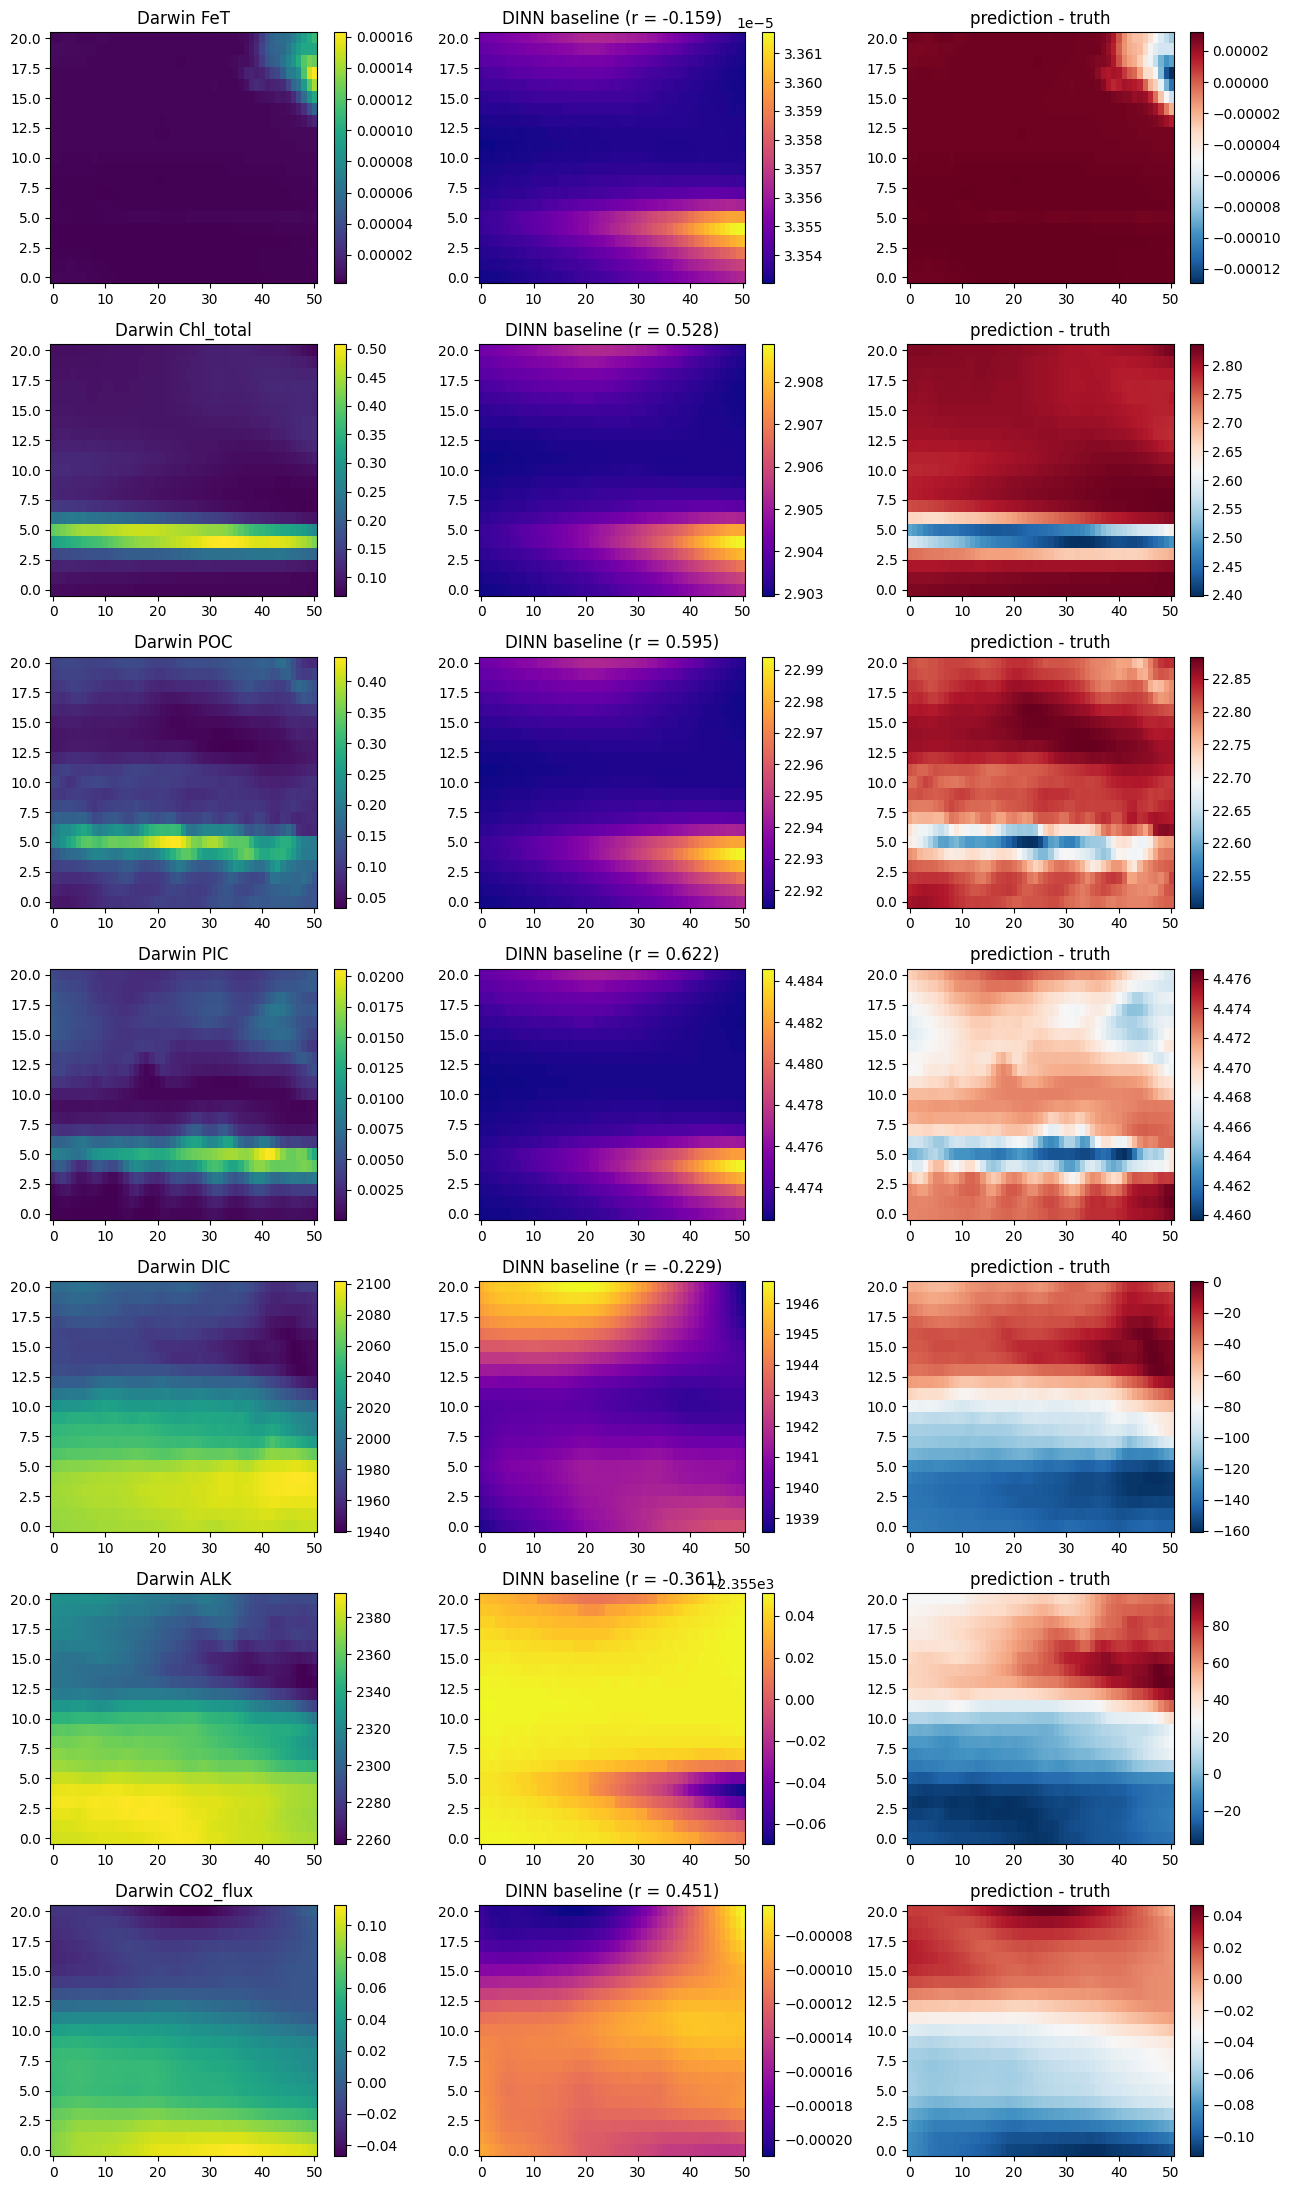

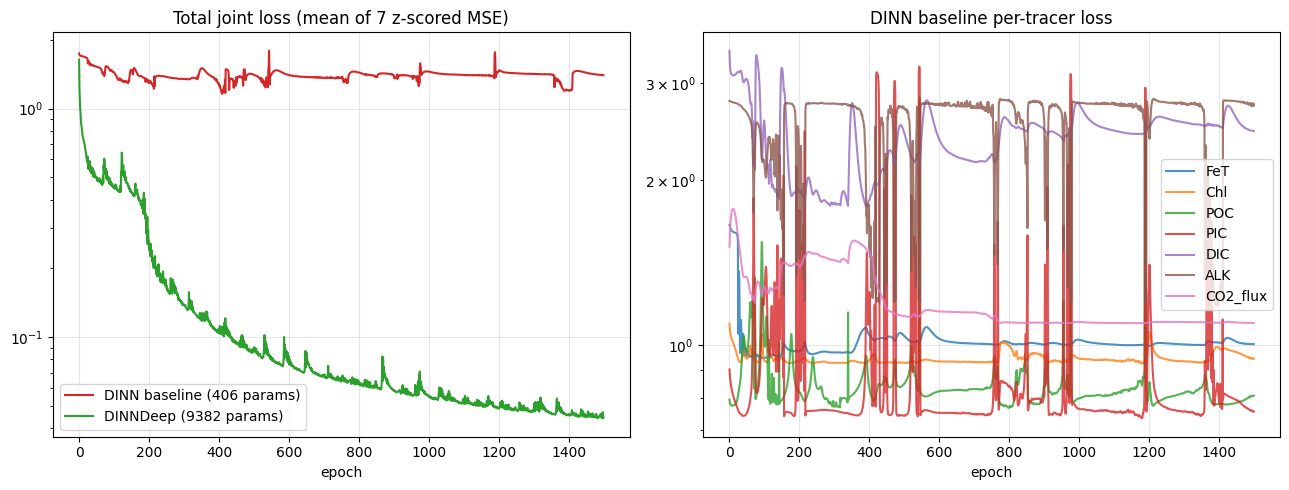

In [6]:
tracers = [
    ("FeT",      fet_binned,    r_baseline["dfe_final"]),
    ("Chl_total", chl_total,    r_baseline["phyto_final"]),
    ("POC",      poc_binned,    r_baseline["poc_final"]),
    ("PIC",      pic_binned,    r_baseline["pic_final"]),
    ("DIC",      dic_binned,    r_baseline["dic_final"]),
    ("ALK",      alk_binned,    r_baseline["alk_final"]),
    ("CO2_flux", co2_flux_obs,  r_baseline["co2_flux_final"]),
]

fig, axes = plt.subplots(7, 3, figsize=(13, 22))
for row, (name, target, pred) in enumerate(tracers):
    target_plot = np.where(ocean_mask, target, np.nan)
    pred_plot = np.where(ocean_mask, pred, np.nan)
    err_plot = np.where(ocean_mask, pred - target, np.nan)
    r_lookup = name if name != "Chl_total" else "Chl"

    im0 = axes[row, 0].imshow(target_plot, origin="lower", aspect="auto", cmap="viridis")
    axes[row, 0].set_title(f"Darwin {name}")
    plt.colorbar(im0, ax=axes[row, 0])

    rb = r_per_b[r_lookup]
    im1 = axes[row, 1].imshow(pred_plot, origin="lower", aspect="auto", cmap="plasma")
    axes[row, 1].set_title(f"DINN baseline (r = {rb.r:.3f})")
    plt.colorbar(im1, ax=axes[row, 1])

    im2 = axes[row, 2].imshow(err_plot, origin="lower", aspect="auto", cmap="RdBu_r")
    axes[row, 2].set_title("prediction - truth")
    plt.colorbar(im2, ax=axes[row, 2])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].semilogy(r_baseline["losses"], label=f"DINN baseline ({n_b} params)", color="tab:red")
axes[0].semilogy(r_deep["losses"], label=f"DINNDeep ({n_d} params)", color="tab:green")
axes[0].set_title("Total joint loss (mean of 7 z-scored MSE)")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

for tracer in ["FeT", "Chl", "POC", "PIC", "DIC", "ALK", "CO2_flux"]:
    axes[1].semilogy(r_baseline["losses_per_tracer"][tracer], label=tracer, alpha=0.8)
axes[1].set_title("DINN baseline per-tracer loss")
axes[1].set_xlabel("epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## What this notebook tests — and what to do with the result

Two decisions, headlined by the **DINN baseline** result (not DINNDeep):

1. **Headline: does the iron pair move?** Compare DINN-baseline + 7-tracer carbonate (this notebook) against DINN-baseline + FeT-only (nb14) on the same AOI + same architecture. The carbonate signal is the ONLY thing different.
   - **`alpfe` and `scav_rat` closer to Carroll's published** → the carbonate extension was the missing constraint. Track 1 v2.0 result: differentiable physics with the right box model + the right loss surfaces produces calibration-grade parameter recovery on local hardware. The cluster ask shifts to "scale this to full ocean / time-resolved" with cleaner identifiability.
   - **Iron pair stays off** → the remaining gap is something the local + bin_average + native LLC270 surface setup can't close. Strongest candidates (in order of likelihood): (a) depth-resolved iron observations to constrain scavenging, (b) full Darwin-3 ecosystem (5 PFTs) beyond the 5-tracer proxy, (c) time-resolved fitting to break additional degeneracies. All three are cluster-gated — that becomes the next compute proposal.

2. **Secondary: does DINNDeep + 7-tracer move closer than DINNDeep + 4-tracer (nb19)?** Continues the saturation-ceiling story. If yes, the box-model extension matters even at saturated fit quality; if no, joint-loss tracer count is the limit and the next move is the box model itself. DINNDeep r → 1.000 expected on every tracer — that's the ceiling, not the scientific claim.

**What stays unchanged regardless of outcome:**
- Per-cell architecture (1×1 conv backbone, no spatial coupling) — the DINN-vs-global-scalar structural argument that's been the project's headline since v1.0
- Sigmoid bounding into Carroll's PARAM_BOUNDS
- Forward-Euler integration at dt=0.25 d, 200 steps, 1500 epochs
- Eq Pacific AOI (5°S–15°N × 160°W–110°W)

**The honest framing this enables:** DarwinDiff functions as a differentiable-physics *calibration tool* for ECCO-Darwin BGC parameters (not just a diagnostic — the v1.8 framing). Locally-runnable, ~45–60 min on a single GPU, ships in v2.0.
